# PBMC 1K GEX — Post-Processing Analysis

This notebook is a companion to the [PBMC 1K GEX tutorial](../PBMC_GEX.md). It assumes you have already run the `sc-preprocess` pipeline and have a processed output directory at `1K_PBMC_GEX_PROCESSED/`.

**What this notebook covers:**
1. Loading the pipeline output
2. Inspecting the AnnData object and traceability metadata
3. GEX quality control
4. Doublet score inspection

## Setup

Set `H5AD_PATH` to the path of your pipeline output file.

In [1]:
import scanpy as sc

# Path to the final pipeline output — update this to match your output directory
H5AD_PATH = "../PBMC_1K_GEX/1K_PBMC_GEX_PROCESSED/08_FINAL/1_gex.h5ad"

## Load the data

In [2]:
adata = sc.read_h5ad(H5AD_PATH)
adata

AnnData object with n_obs × n_vars = 1015 × 36601
    obs: 'batch_id', 'capture_id', 'cell_id', 'barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_scrublet_scrublet_score', 'doublet_scrublet_scrublet_predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

## Verify traceability metadata

Every cell should have `batch_id`, `capture_id`, and a globally unique `cell_id`.

In [3]:
assert "batch_id" in adata.obs.columns
assert "capture_id" in adata.obs.columns
assert "cell_id" in adata.obs.columns
assert adata.obs["cell_id"].is_unique, "cell_id must be unique!"

print(f"Total cells : {adata.n_obs}")
print(f"Total genes : {adata.n_vars}")
print()
print(adata.obs[["batch_id", "capture_id", "cell_id"]].head())

Total cells : 1015
Total genes : 36601

                          batch_id capture_id                    cell_id
cell_id                                                                 
1_L001_AAACCTGAGCGCTCCA-1        1       L001  1_L001_AAACCTGAGCGCTCCA-1
1_L001_AAACCTGGTGATAAAC-1        1       L001  1_L001_AAACCTGGTGATAAAC-1
1_L001_AAACGGGGTTTGTGTG-1        1       L001  1_L001_AAACGGGGTTTGTGTG-1
1_L001_AAAGATGAGTACTTGC-1        1       L001  1_L001_AAAGATGAGTACTTGC-1
1_L001_AAAGCAAGTCTCTTAT-1        1       L001  1_L001_AAAGCAAGTCTCTTAT-1


## GEX quality control

Key metrics to inspect:
- `total_counts` — total UMI counts per cell
- `n_genes_by_counts` — number of detected genes per cell
- `pct_counts_mt` — percent mitochondrial counts (high values indicate damaged cells)

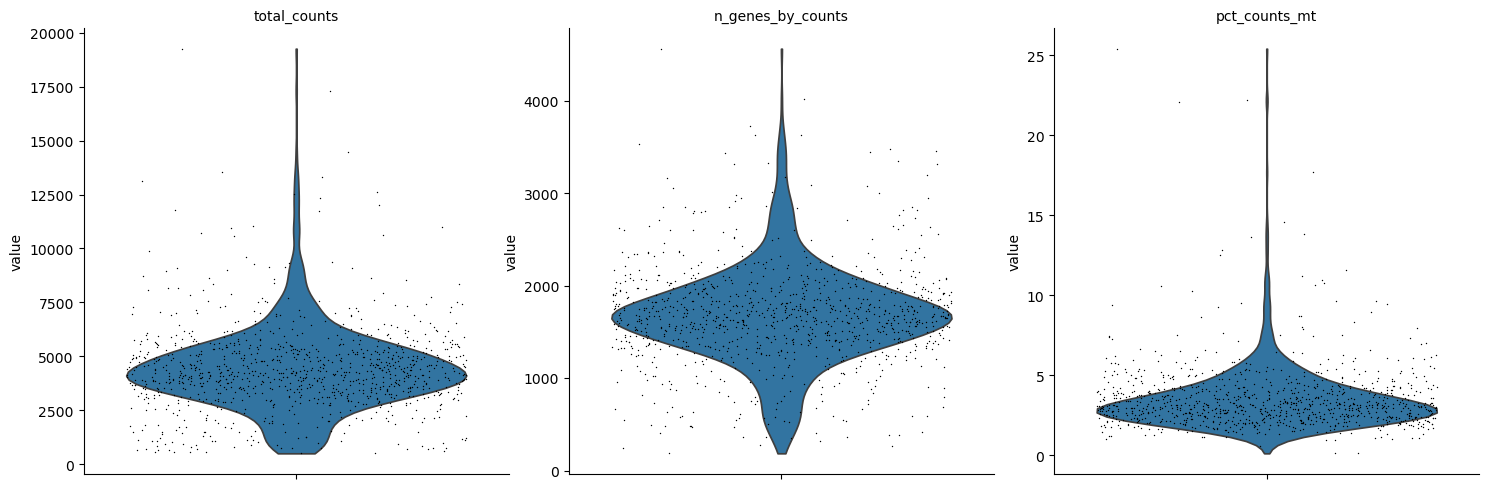

In [4]:
sc.pl.violin(
    adata,
    ["total_counts", "n_genes_by_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

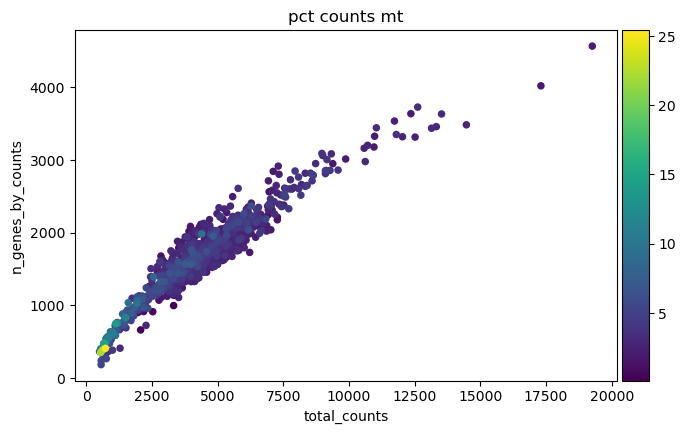

In [5]:
sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt",
)

Ribosomal gene content is another useful QC metric:

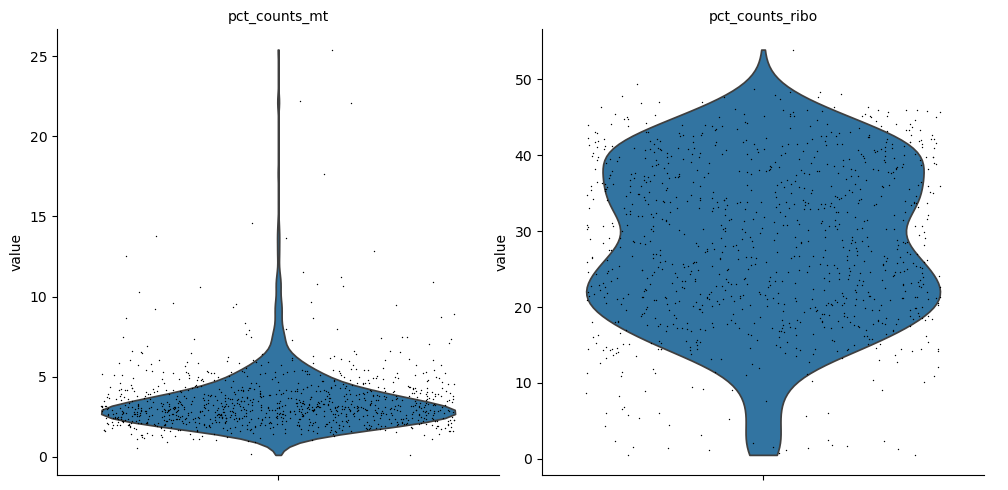

In [6]:
sc.pl.violin(
    adata,
    ["pct_counts_mt", "pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True,
)

## Doublet scores

Scrublet doublet scores are stored in `doublet_scrublet_scrublet_score` and predictions in `doublet_scrublet_scrublet_predicted_doublet`.

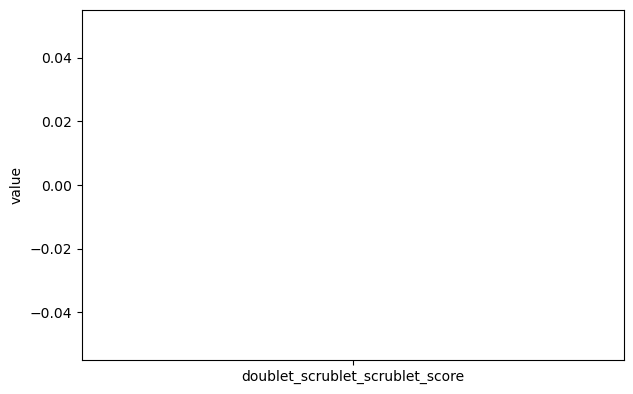

In [7]:
sc.pl.violin(
    adata,
    "doublet_scrublet_scrublet_score",
    jitter=0.4,
)

In [8]:
predicted = adata.obs["doublet_scrublet_scrublet_predicted_doublet"]
n_doublets = (predicted == 1.0).sum()
n_singlets = (predicted == 0.0).sum()

print(f"Predicted singlets : {n_singlets}")
print(f"Predicted doublets : {n_doublets} ({100 * n_doublets / len(predicted):.1f}%)")

Predicted singlets : 0
Predicted doublets : 0 (0.0%)
